Ingestion Complete
                     reading
ts                          
2024-05-01 00:00:00    22.50
2024-05-01 00:15:00    22.65
2024-05-01 00:30:00    22.80
2024-05-01 00:45:00    22.95
2024-05-01 01:00:00    23.10
count    197.000000
mean      24.841117
std        1.440370
min       22.400000
25%       23.600000
50%       24.900000
75%       26.100000
max       27.300000
Name: reading, dtype: float64


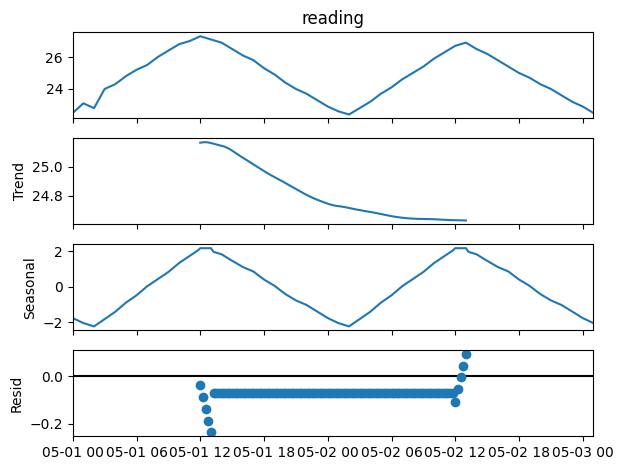

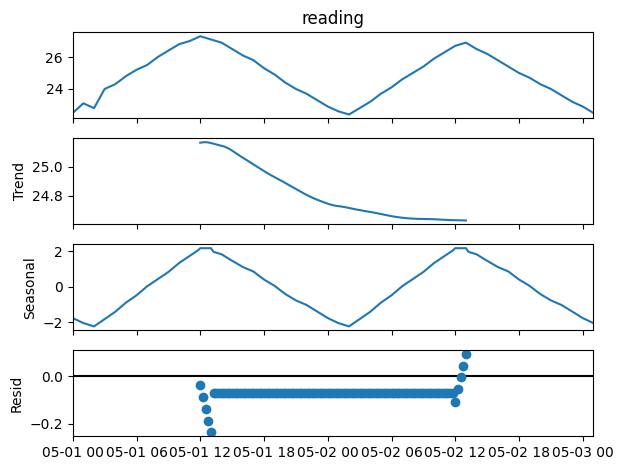

In [9]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose


# MODULE 1: INGESTION

def ingestion_module(input_file, output_file):

    df = pd.read_csv(input_file)

    # Correct timestamp format
    df['ts'] = pd.to_datetime(
        df['ts'],
        format='%y/%m/%d %H:%M'
    )

    # Set timestamp index
    df.set_index('ts', inplace=True)

    # Save parquet
    df.to_parquet(output_file)

    return "Ingestion Complete"



# MODULE 2: PREPARATION

def preparation_module(input_file):

    df = pd.read_parquet(input_file)

    # Sort timestamps
    if not df.index.is_monotonic_increasing:
        df = df.sort_index()

    # Resampling
    df_structured = df.resample('15min').mean()

    # Interpolation
    df_structured['reading'] = df_structured[
        'reading'
    ].interpolate(method='time')

    return df_structured



# MODULE 3: EXPLORATION

def exploration_module(df, period_val=96):

    analysis = seasonal_decompose(
        df['reading'],
        model='additive',
        period=period_val
    )

    stats = df['reading'].describe()

    return analysis, stats



# MAIN EXECUTION

print(
    ingestion_module(
        'lab_sensor.csv',
        'sensor_cache.parquet'
    )
)

prepared_df = preparation_module(
    'sensor_cache.parquet'
)

print(prepared_df.head())

analysis, stats = exploration_module(
    prepared_df
)

print(stats)

analysis.plot()